# Customer Segmentation with KMeans

This notebook demonstrates how we can use **KMeans clustering** to group customers into segments.  
It is the *technical companion* to the business presentation and provides both:
- **Simple explanations** for decision makers
- **Engineering notes** for technical reviewers

The analysis is based on customer transaction data with the following columns:
- **Account No.** → Unique customer identifier  
- **Sales (FUSD)** → Total sales amount in functional USD  
- **Receipt No.** → Unique receipt identifier (used for frequency)  
- **Date** → Date of transaction  

We will:
1. Prepare Recency, Frequency, and Monetary (RFM) features
2. Compare clustering with **raw data** vs **square-root transformed data**
3. Evaluate results with metrics and visualizations
4. Build a reusable **pipeline function**


In [3]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Clustering and evaluation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# For reproducibility
RANDOM_STATE = 42


## Load Data

We start by loading the transactional data.  
Each row represents a **single receipt line**, so we need to aggregate at the customer level.


In [4]:
# Load data
file_path = r"C:\Users\mohamad.ibrahim\OneDrive - UCCM\Desktop\CustomerData.xlsx"
df = pd.read_excel(file_path)

# Convert to functional USD
df['Sales (FUSD)'] = df['POS Sold Value'] / 89750

# Remove rows with missing Phone No. or Account No.
before = len(df)
df = df.dropna(subset=['Phone No_', 'Account No_'])
after = len(df)
print(f"Removed {before - after} rows with missing Phone No_ or Account No_")

df.head()


Removed 0 rows with missing Phone No_ or Account No_


,Account No_,Phone No_,Date,Time,Store Name,Receipt No_,Item,POS Quantity Sold,POS Sold Value,Sales (FUSD)
0,10000000,10000000,2024-09-25,11:46:34.897000,Store 1,REC0000000000000001,1000000,1.0,141498.20,1.576582
1,10000000,10000000,2024-09-25,11:46:50.927000,Store 1,REC0000000000000001,1000000,1.0,141498.20,1.576582
2,10000001,10000001,2024-09-08,13:23:57.433000,Store 2,REC0000000000000002,1000002,2.0,64576.58,0.719516
3,10000002,10000002,2024-09-01,13:21:12.507000,Store 1,REC0000000000000003,1000000,1.0,141261.26,1.573942
4,10000003,10000003,2024-09-24,11:32:52.443000,Store 1,REC0000000000000004,1000002,1.0,32342.34,0.360360


## Feature Engineering: RFM

We build customer-level features:

- **Monetary** = total Sales (FUSD)  
- **Frequency** = unique Receipt No_ (proxy for visits)  
- **Recency** = days since last purchase (relative to cutoff date)  
- **First Purchase Date** = earliest known transaction for each customer  

The **First Purchase Date** is crucial for separating:
- **New Customers**: first-ever purchase is recent  
- **Dormant Customers**: had past purchases but no recent activity  

This prevents false “new” labels when old customers reappear after long inactivity.

🔧 *Engineer note*:  
We merge `first_purchase_date` into the RFM table, so every customer carries both their latest and earliest activity dates.


df.head()


In [5]:
# Ensure Date column is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Cutoff date = latest date in dataset
cutoff_date = df['Date'].max()

# Group for RFM
rfm = df.groupby('Account No_').agg({
    'Sales (FUSD)': 'sum',
    'Receipt No_': 'nunique',
    'Date': 'max'
}).rename(columns={
    'Sales (FUSD)': 'Monetary',
    'Receipt No_': 'Frequency',
    'Date': 'Last Purchase Date'
})

# Calculate Recency
rfm['Recency'] = (cutoff_date - rfm['Last Purchase Date']).dt.days

# Add First Purchase Date
first_purchase_date = df.groupby('Account No_')['Date'].min().reset_index()
first_purchase_date.rename(columns={'Date': 'First Purchase Date'}, inplace=True)

rfm = rfm.merge(first_purchase_date, on='Account No_', how='left')

rfm.head()


,Account No_,Monetary,Frequency,Last Purchase Date,Recency,First Purchase Date
0,10000000,156.923736,6,2024-09-29,1,2024-09-24
1,10000001,34.355134,4,2024-09-08,22,2024-07-07
2,10000002,222.782598,38,2024-09-18,12,2024-01-16
3,10000003,1772.216637,124,2024-09-29,1,2024-01-02
4,10000004,202.801255,82,2024-09-30,0,2024-01-10


## Raw vs. Square-root Transformation

The three RFM features (Recency, Frequency, Monetary) often have very different scales:
- Recency can be **hundreds of days**
- Frequency is usually **small integers**
- Monetary can be **heavily skewed by big spenders**

This imbalance makes KMeans biased, because it relies on **Euclidean distance**.  
If one variable dominates in scale, clusters are shaped mostly by that feature.

### Why Square-root Transformation?
- **Business-level**: it smooths out extreme spenders or very frequent visitors, so clusters represent *typical customers* rather than just outliers.  
- **Engineer-level**: sqrt reduces skewness and compresses large values, improving distance calculations in KMeans.

We will:
1. Compare histograms of raw vs. sqrt data
2. Prepare both versions
## Transformation Strategy

We treat Recency differently from Frequency and Monetary:

- **Recency**: left as-is, because it represents a clear business metric (days).  
  Later, we apply **manual bins** (e.g., 0–14 days = "very recent", etc.).  

- **Frequency & Monetary**: apply √ transformation to reduce skew and prevent outliers from dominating.  

This approach keeps Recency interpretable for business rules, while making Frequency/Monetary clustering more stable.
 for clustering


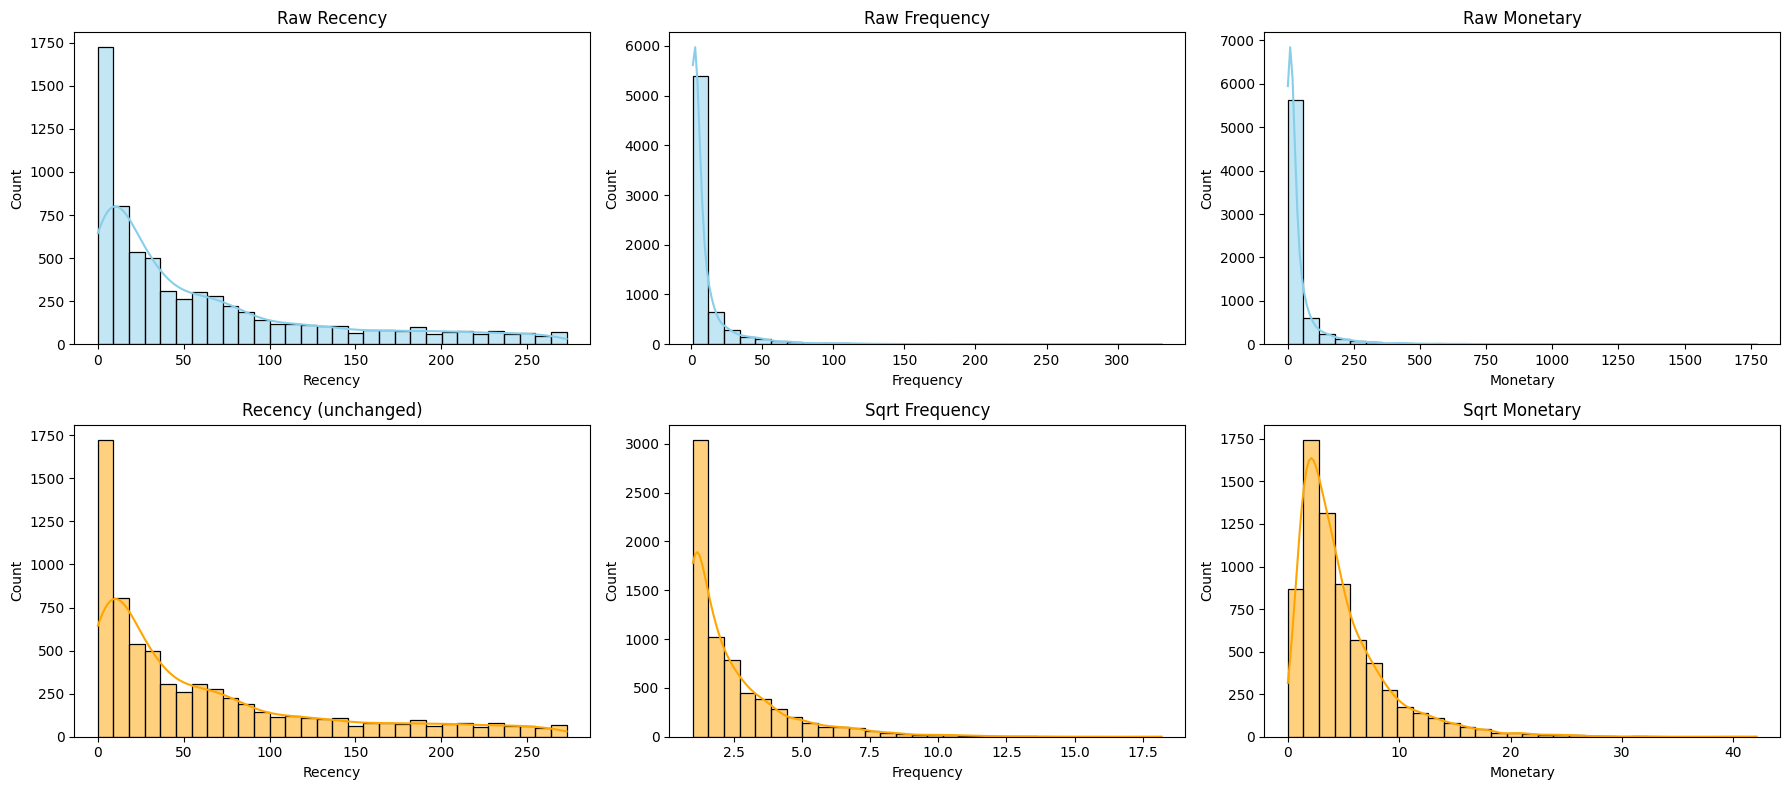

In [6]:
# Select features
features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# Apply sqrt only to Frequency and Monetary
X_sqrt = features.copy()
X_sqrt['Frequency'] = np.sqrt(X_sqrt['Frequency'])
X_sqrt['Monetary'] = np.sqrt(X_sqrt['Monetary'])

# Histograms: Raw vs Sqrt (Recency untouched, Frequency & Monetary transformed)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(features.columns):
    # Raw
    sns.histplot(features[col], bins=30, ax=axes[0, i], kde=True, color="skyblue")
    axes[0, i].set_title(f"Raw {col}")
    
    # Transformed
    sns.histplot(X_sqrt[col], bins=30, ax=axes[1, i], kde=True, color="orange")
    axes[1, i].set_title(f"Sqrt {col}" if col != 'Recency' else "Recency (unchanged)")

plt.tight_layout()
plt.show()


## Why Apply Transformations?

It is important to clarify that **we are not changing the data** — we are **scaling it for fairness**.

- **Raw values are untouched in the database**.  
- Transformations are only used during clustering to prevent one variable (like big spenders) from dominating the grouping.  

### Business explanation:
- Imagine one customer spends \$10,000 and another spends \$100.  
  Without transformation, the algorithm sees them as “100× different,”  
  even if their behavior pattern is otherwise similar.  
- By compressing extreme values (using square root), we ensure **all customers count**, not just outliers.  

### Technical explanation:
- KMeans uses **Euclidean distance**.  
- If one feature (Monetary) spans thousands, and another (Frequency) only goes up to tens,  
  the larger scale feature dominates distance calculations.  
- Square-root reduces skewness and balances contribution of features.  

✅ **Key point**: Transformations are for the algorithm’s math, not for reporting.  
When we profile and report clusters back to business, we always use the **raw Recency, Frequency, Monetary values**.


## KMeans Clustering (Raw vs Sqrt)

We run KMeans on both raw and sqrt-transformed features for comparison.

- **Cluster count (k=4)**: chosen for demonstration, but in practice can be tuned (Elbow/Silhouette).  
- Each version will give different boundaries because of scaling.  
- We will compare:
  - Inertia (within-cluster variance)
  - Silhouette score
  - Davies–Bouldin index


In [7]:
def run_kmeans(X, n_clusters=4, random_state=RANDOM_STATE):
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(X)
    inertia = kmeans.inertia_
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    return labels, inertia, sil, db, kmeans

# Prepare inputs for clustering
X_raw = rfm[['Frequency', 'Monetary']]   # raw Frequency & Monetary
X_sqrt = np.sqrt(X_raw)                  # sqrt transform applied

# Run KMeans for raw
labels_raw, inertia_raw, sil_raw, db_raw, model_raw = run_kmeans(X_raw)

# Run KMeans for sqrt
labels_sqrt, inertia_sqrt, sil_sqrt, db_sqrt, model_sqrt = run_kmeans(X_sqrt)

# Attach labels back to RFM
rfm['Cluster_Raw'] = labels_raw
rfm['Cluster_Sqrt'] = labels_sqrt

# Print evaluation
print("Raw F/M:   Inertia =", inertia_raw, "Silhouette =", sil_raw, "DB =", db_raw)
print("Sqrt F/M: Inertia =", inertia_sqrt, "Silhouette =", sil_sqrt, "DB =", db_sqrt)

# Create a lookup: cluster -> avg F/M
cluster_order = rfm.groupby('Cluster_Sqrt')[['Frequency','Monetary']].mean()
cluster_order['Score'] = cluster_order['Frequency'] + cluster_order['Monetary']
cluster_order = cluster_order.sort_values('Score').reset_index()

# Map old labels to new sorted labels
mapping = {old:new for new, old in enumerate(cluster_order['Cluster_Sqrt'])}
rfm['Cluster_Sqrt'] = rfm['Cluster_Sqrt'].map(mapping)


Raw F/M:   Inertia = 8299324.11214285 Silhouette = 0.7803945112064551 DB = 0.57013472457258
Sqrt F/M: Inertia = 20774.102776701424 Silhouette = 0.5285995024574861 DB = 0.684610726596995


In [8]:
# Evaluate clustering quality
eval_df = pd.DataFrame({
    "Version": ["Raw", "Sqrt"],
    "Inertia": [inertia_raw, inertia_sqrt],
    "Silhouette": [sil_raw, sil_sqrt],
    "DB Index": [db_raw, db_sqrt]
})
eval_df


,Version,Inertia,Silhouette,DB Index
0,Raw,8.299324e+06,0.780395,0.570135
1,Sqrt,2.077410e+04,0.528600,0.684611


## Visualizing Clusters

To understand cluster separation:
- We plot scatterplots for Monetary and Frequency vs Monetary.
- We also use PCA (Principal Component Analysis) to project 3D data into 2D.

🔧 *Engineer note*:  
PCA doesn’t change the clustering, it just makes it easier to visualize in 2D.


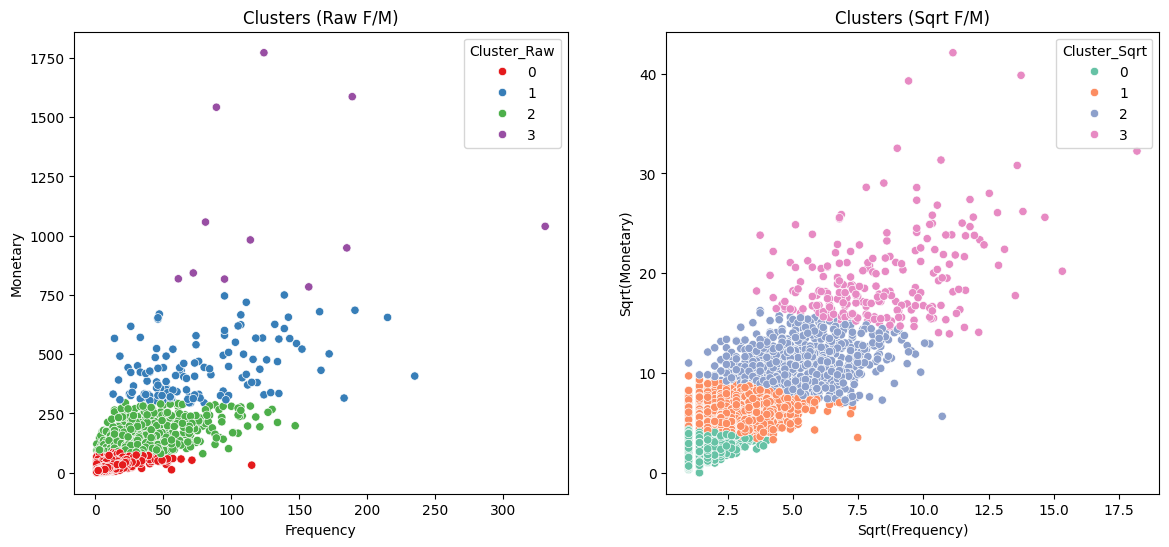

In [9]:
# Scatterplot for Raw vs Sqrt clusters (Frequency vs Monetary)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=rfm['Frequency'], y=rfm['Monetary'],
                hue=rfm['Cluster_Raw'], palette="Set1", ax=axes[0])
axes[0].set_title("Clusters (Raw F/M)")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Monetary")

sns.scatterplot(x=np.sqrt(rfm['Frequency']), y=np.sqrt(rfm['Monetary']),
                hue=rfm['Cluster_Sqrt'], palette="Set2", ax=axes[1])
axes[1].set_title("Clusters (Sqrt F/M)")
axes[1].set_xlabel("Sqrt(Frequency)")
axes[1].set_ylabel("Sqrt(Monetary)")

plt.show()


## Interpreting the F vs M Cluster Plots

Each point on the scatterplot represents **one customer**:
- **X-axis (Frequency):** how many times the customer visited (unique receipts).  
- **Y-axis (Monetary):** how much they spent in total (USD).  

The colors show the groups (clusters) found by KMe meaning.

### What the plots show:
- **Raw F/M (left):**  
  - Clusters are distorted by extreme outliers.  
  - Most customers are squeezed in the bottom-left corner, making separation unclear.  

- **Sqrt F/M (right):**  
  - By compressing extreme values, we get a fairer spread of customers.  
  - Clusters now align with recognizable customer types:  
    - Low frequency, low spenders  
    - Frequent but low spenders  
    - Rare but big spenders  
    - Frequent and high spenders (loyal champions)  

### Why this is good:
- As we move **right**, we also move **up** — customers who visit more often also tend to spend more, which matches real business logic.  
- The clusters are **separated but not random** — not too compressed (indistinguishable), not too spread out (overfitting).  
- This balance shows that both Frequency and Monetary contribute meaningfully to segmentation.


## Recency Binning & Rolling Window

We kept Recency **out of KMeans** because it has a clear business interpretation:  
- It measures how many days since the last purchase.  
- Instead of clustering, we apply **manual bins** (business rules).

### Why bins?
- **Business view:** It’s easier to say *“customers inactive for >60 days are at risk”* than to explain a mathematical cluster.  
- **Engineer view:** Recency is highly skewed and dominates Euclidean distance; bins preserve interpretability.

### Why a 6-month rolling window?
- **Business view:** In retail, customer behavior can change quickly. A 6-month cutoff balances recency (short-term activity) with loyalty (long-term history).  
- **Engineer view:** Using a fixed rolling window ensures segmentation updates consistently over time.

✅ Important rule:  
If a customer purchased 7 months ago and comes back today, they are **not new** (because their first purchase date is much earlier).  
That’s why we store both *Recency* and *First Purchase Date*.


## Segmentation Engine (Reusable & Scalable)

**What this does**
- Builds RFM: Monetary (sum of `Sales (FUSD)`), Frequency (nunique `Receipt No_`), Recency (days since last purchase).
- **Recency** is *not* clustered; it’s binned manually (business interpretability).
- **Frequency & Monetary** are each clustered **separately** with 1-D KMeans → scores 1..4 after centroid-based relabeling.
- Final segment rules: “New”, “One Time Visitor”, “Champion”, “Loyal”, etc.
- 6-month rolling window: recomputes segments month-by-month and logs metrics for technical validation.(Can be done bi weekly or weekly)

**Engineering upgrades**
- Clear config switches (choose raw vs sqrt per feature).
- Defensive cleaning & stable random seeds.
- Small testable functions with single responsibilities.
- Deterministic label re-ordering (lowest→highest).
- Optional evaluation metrics (Silhouette, CH, DB) for the tech team.

> Note: Since we're analyzing only a subset of stores/categories, clusters/metrics reflect that slice. When scaling to full receipts, expect metric changes and re-tuning.


In [10]:
from __future__ import annotations
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Dict, Tuple, List
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from dateutil.relativedelta import relativedelta

RANDOM_STATE = 42

@dataclass(frozen=True)
class SegmentConfig:
    # Recency binning (manual, business-led)
    recency_bins: Tuple[float, ...] = (-1, 15, 35, 60, float("inf"))  # (-1,15], (15,35], (35,60], (60, inf)
    recency_labels: Tuple[int, ...] = (4, 3, 2, 1)  # 4=very recent … 1=dormant
    new_days: int = 30
    rolling_window_months: int = 6

    # 1-D KMeans scores for Frequency & Monetary
    n_clusters_f: int = 4
    n_clusters_m: int = 4
    random_state: int = RANDOM_STATE
    n_init: int = 10

    # Transformation toggles (so you can compare raw vs sqrt without code changes)
    use_sqrt_frequency: bool = False  # set True to mimic your earlier sqrt+floor flow
    use_sqrt_monetary:  bool = False  # set True to mimic your earlier sqrt+1 flow
    sqrt_add_one: bool   = True       # sqrt(x+1) to handle zeros
    sqrt_floor_freq: bool = True      # preserve your floor on freq if sqrt is used

CFG = SegmentConfig()

def ensure_types_and_clean_base(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Required columns must exist
    required = {'Account No_', 'Receipt No_', 'Date', 'Sales (FUSD)', 'Phone No_'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    # Drop rows without IDs
    before = len(df)
    df = df.dropna(subset=['Phone No_', 'Account No_'])
    after = len(df)
    print(f"[Clean] Removed {before - after} rows with missing Phone No_ or Account No_")
    # Date to datetime
    df['Date'] = pd.to_datetime(df['Date'])
    return df

def build_rfm(df: pd.DataFrame, cutoff_date: pd.Timestamp) -> pd.DataFrame:
    """Aggregate to customer level: Monetary, Frequency, Last/First Purchase, Recency."""
    grp = df.groupby('Account No_').agg({
        'Sales (FUSD)': 'sum',
        'Receipt No_':  'nunique',
        'Date':         ['max', 'min']
    })
    grp.columns = ['Monetary', 'Frequency', 'Last Purchase Date', 'First Purchase Date']
    # Defensive clipping before any transform
    grp['Monetary'] = grp['Monetary'].fillna(0).clip(lower=0)
    grp['Frequency'] = grp['Frequency'].fillna(0).clip(lower=0)
    grp['Recency'] = (cutoff_date - grp['Last Purchase Date']).dt.days
    # Drop impossible rows
    grp = grp.dropna(subset=['Recency', 'First Purchase Date', 'Last Purchase Date'])
    return grp

def maybe_transform_series(s: pd.Series, do_sqrt: bool, add_one=True, floor=False) -> pd.Series:
    if not do_sqrt:
        return s
    x = s + (1 if add_one else 0)
    x = np.sqrt(x)
    if floor:
        x = np.floor(x).astype(int)
    return x

def kmeans_1d_labels_sorted(x: pd.Series, n_clusters: int, random_state: int, n_init: int
                            ) -> Tuple[pd.Series, Dict[str, float]]:
    """Fit 1-D KMeans, relabel clusters 1..k by increasing centroid; return labels & metrics."""
    arr = x.values.reshape(-1, 1)
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)
    labels = km.fit_predict(arr)
    # Relabel by centroid order (lowest -> 1, highest -> k)
    centers = km.cluster_centers_.ravel()
    order = np.argsort(centers)
    mapping = {old: new+1 for new, old in enumerate(order)}
    labels_ordered = pd.Series([mapping[l] for l in labels], index=x.index, name=f"{x.name}_score")

    # Metrics (for tech validation; keep, but you can hide in slides)
    sil = silhouette_score(arr, labels) if len(np.unique(labels)) > 1 else np.nan
    ch  = calinski_harabasz_score(arr, labels) if len(np.unique(labels)) > 1 else np.nan
    db  = davies_bouldin_score(arr, labels) if len(np.unique(labels)) > 1 else np.nan
    metrics = {"silhouette": float(sil), "calinski_harabasz": float(ch), "davies_bouldin": float(db)}
    return labels_ordered, metrics

def recency_score(recency_days: pd.Series, bins: Tuple[float, ...], labels: Tuple[int, ...]) -> pd.Series:
    r = pd.cut(recency_days, bins=bins, labels=labels).astype(int)
    r.name = "Recency_score"
    return r


In [11]:
from pandas.tseries.offsets import MonthEnd

def fit_reference_thresholds(df_all, ref_end, months=12, cfg: SegmentConfig=CFG):
    # Fit once on last `months` to learn stable cut points
    ref_end   = pd.to_datetime(ref_end) + MonthEnd(0)
    ref_start = (ref_end - pd.DateOffset(months=months-1)).replace(day=1)
    df_ref = df_all[(df_all['Date'] >= ref_start) & (df_all['Date'] <= ref_end)].copy()
    rfm_ref = build_rfm(df_ref, ref_end)

    F_ref = maybe_transform_series(rfm_ref['Frequency'], cfg.use_sqrt_frequency, cfg.sqrt_add_one, cfg.sqrt_floor_freq)
    M_ref = maybe_transform_series(rfm_ref['Monetary'],  cfg.use_sqrt_monetary,  cfg.sqrt_add_one, False)

    km_f = KMeans(n_clusters=cfg.n_clusters_f, random_state=cfg.random_state, n_init=cfg.n_init).fit(F_ref.values.reshape(-1,1))
    km_m = KMeans(n_clusters=cfg.n_clusters_m, random_state=cfg.random_state, n_init=cfg.n_init).fit(M_ref.values.reshape(-1,1))

    cF = np.sort(km_f.cluster_centers_.ravel())
    cM = np.sort(km_m.cluster_centers_.ravel())
    thrF = (cF[:-1] + cF[1:]) / 2.0   # midpoints → thresholds
    thrM = (cM[:-1] + cM[1:]) / 2.0
    return {"freq_thr": thrF, "mon_thr": thrM}

def score_by_thresholds(x: pd.Series, thresholds: np.ndarray) -> pd.Series:
    # returns labels 1..k where k = len(thresholds)+1
    labels = np.digitize(x.values, thresholds, right=False) + 1
    return pd.Series(labels, index=x.index)


## Segment Assignment

Once Recency, Frequency, and Monetary are scored, we map them into **business segments**.  
This is where abstract scores (1–4) turn into meaningful labels such as:

- **Champion** → very recent, high frequency, high monetary.  
- **Loyal Low Spender** → active, visits often, but low basket size.  
- **At Risk / Dormant** → customers who haven’t purchased recently.  
- **New** → first purchase within the last 30 days.  
- **One Time Visitor** → exactly one purchase in history.  

This mapping is rule-based for transparency.  
It ensures segmentation remains **consistent, interpretable, and aligned with business strategy**.


In [12]:
def assign_segment_row(row, cutoff_date: pd.Timestamp, cfg: SegmentConfig) -> str:
    r, f, m = row['Recency_score'], row['Frequency_score'], row['Monetary_score']
    first, last = row['First Purchase Date'], row['Last Purchase Date']

    # New within cfg.new_days window
    if (cutoff_date - first).days <= cfg.new_days:
        return 'New'
    # One-time visitor
    if pd.Timestamp(first) == pd.Timestamp(last):
        return 'One Time Visitor'
    # Your rules
    if (r == 4 and f == 4 and m == 4):
        return 'Champion'
    if (r in [3, 4] and f in [3, 4] and m in [1, 2]):
        return 'Loyal Low Spender'
    if (r in [3, 4] and f in [1, 2] and m in [1, 2]):
        return 'Low activity'
    if (r in [3, 4] and f in [3, 4] and m in [3, 4]):
        return 'Loyal'
    if (r in [3, 4] and f in [1, 2] and m in [3, 4]):
        return 'Loyal not frequent'
    if r == 2:
        return 'At Risk'
    if r == 1:
        return 'Dormant'
    return 'Other'


## Single-Cutoff Segmentation (Engine)

The function `create_segmented_df` runs the **segmentation engine** for a chosen cutoff date:

1. **Build RFM:**  
   - Aggregate sales, visits, and recency at customer level.  

2. **Transform & Cluster F/M:**  
   - Frequency and Monetary can be left raw or sqrt-transformed (toggle via config).  
   - 1-D KMeans assigns scores 1–4, relabeled by centroid order.  

3. **Manual Recency Bins:**  
   - Days since last purchase are mapped to scores (4=very recent … 1=dormant).  

4. **Segment Assignment:**  
   - Apply business rules (Champions, At Risk, etc.).  

5. **Outputs:**  
   - A customer-level DataFrame with R/F/M scores and segment.  
   - Clustering metrics (Silhouette, CH, DB) for technical validation.  

This cell is the **core reusable engine**.  
It doesn’t care how much history is passed (1 month, 6 months, 12 months).  
That choice is enforced by the rolling-window driver.


In [13]:
def create_segmented_df(df_filtered: pd.DataFrame,
                        cutoff_date: pd.Timestamp,
                        cfg: SegmentConfig = CFG,
                        ref_thr: Dict[str, np.ndarray] | None = None) -> Tuple[pd.DataFrame, Dict[str, Dict[str, float]]]:
    # Build RFM on the provided slice (you will pass last 6 months)
    df_grp = build_rfm(df_filtered, cutoff_date)

    # Transforms (policy: F = sqrt+floor (discrete), M = raw unless you toggle)
    F = maybe_transform_series(df_grp['Frequency'], cfg.use_sqrt_frequency, cfg.sqrt_add_one, cfg.sqrt_floor_freq)
    M = maybe_transform_series(df_grp['Monetary'],  cfg.use_sqrt_monetary,  cfg.sqrt_add_one, False)

    if ref_thr is None:
        # fallback: fit per-window (thresholds drift)
        F_labels, F_metrics = kmeans_1d_labels_sorted(F, cfg.n_clusters_f, cfg.random_state, cfg.n_init)
        M_labels, M_metrics = kmeans_1d_labels_sorted(M, cfg.n_clusters_m, cfg.random_state, cfg.n_init)
    else:
        # preferred: fixed thresholds (stable over the year)
        F_labels = score_by_thresholds(F, ref_thr["freq_thr"])
        M_labels = score_by_thresholds(M, ref_thr["mon_thr"])
        F_metrics = {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}
        M_metrics = {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}

    R_labels = recency_score(df_grp['Recency'], cfg.recency_bins, cfg.recency_labels)

    out = df_grp.copy()
    out['Recency_score']   = R_labels
    out['Frequency_score'] = F_labels
    out['Monetary_score']  = M_labels
    out['Segment'] = out.apply(assign_segment_row, axis=1, args=(cutoff_date, cfg))

    return out, {"frequency": F_metrics, "monetary": M_metrics}


## Rolling 6-Month Segmentation

Segmentation should reflect **recent behavior**, not just one month.  
The function `segment_history_over_months` enforces this rule:

- For each cutoff month (e.g., September 2025), it looks back **6 months** of receipts.  
- Runs the segmentation engine (`create_segmented_df`) on that slice.  
- Repeats for previous months (August, July, …).  
- Collects:
  - **Segment history**: how each customer’s segment evolves month-by-month.  
  - **Metrics history**: Silhouette, CH, DB scores per month for Frequency and Monetary clustering.  

This produces a **time-aware segmentation**, letting us track transitions such as:  
- Loyal → At Risk → Dormant  
- New → Loyal → Champion  

It balances short-term recency with long-term loyalty and ensures results are **consistent over time**.


In [14]:
from pandas.tseries.offsets import MonthEnd

def segment_history_over_months(df_all: pd.DataFrame,
                                current_cutoff_date: pd.Timestamp,
                                cfg: SegmentConfig = CFG,
                                window_months: int | None = None,
                                ref_thr: Dict[str, np.ndarray] | None = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if window_months is None:
        window_months = cfg.rolling_window_months

    df_phone = df_all[['Account No_', 'Phone No_']].dropna().drop_duplicates(subset='Account No_')

    seg_frames: List[pd.DataFrame] = []
    months, sil_f, ch_f, db_f, sil_m, ch_m, db_m = [], [], [], [], [], [], []

    curr_eom = pd.to_datetime(current_cutoff_date) + MonthEnd(0)

    for i in range(window_months):
        month_end   = (curr_eom - pd.DateOffset(months=i))                 # EOM
        month_start = (month_end - pd.DateOffset(months=5)).replace(day=1) # first day 5 months earlier
        df_slice = df_all[(df_all['Date'] >= month_start) & (df_all['Date'] <= month_end)].copy()

        seg_df, metrics = create_segmented_df(df_slice, month_end, cfg, ref_thr=ref_thr)
        seg_df = seg_df[['Monetary','Frequency','Recency','Last Purchase Date','First Purchase Date','Segment']]
        seg_df = seg_df.merge(df_phone, on='Account No_', how='left')
        seg_df['Month'] = month_end
        seg_frames.append(seg_df)

        months.append(month_end.strftime('%Y-%m'))
        sil_f.append(metrics['frequency']['silhouette'])
        ch_f.append(metrics['frequency']['calinski_harabasz'])
        db_f.append(metrics['frequency']['davies_bouldin'])
        sil_m.append(metrics['monetary']['silhouette'])
        ch_m.append(metrics['monetary']['calinski_harabasz'])
        db_m.append(metrics['monetary']['davies_bouldin'])

    df_segment_long = (
        pd.concat(seg_frames, ignore_index=True)
          .sort_values(['Account No_', 'Month'])
          .reset_index(drop=True)
    )

    metrics_df = pd.DataFrame({
        'Month': months,
        'Silhouette_Frequency': sil_f, 'CH_Frequency': ch_f, 'DB_Frequency': db_f,
        'Silhouette_Monetary': sil_m, 'CH_Monetary': ch_m, 'DB_Monetary': db_m
    })
    return df_segment_long, metrics_df


## Running the Segmentation

To execute the engine:

1. **Clean & Prepare:**  
   - Ensure key fields (`Account No_`, `Receipt No_`, `Date`, `Sales (FUSD)`, `Phone No_`).  
   - Drop missing IDs, convert dates.

2. **Choose Config:**  
   - Decide whether to use raw or sqrt features for Frequency/Monetary.  
   - Keep parameters (clusters, bins, new_days) consistent across runs.

3. **Single Run (as of today):**  
   - Produces current customer segments at the latest cutoff date.

4. **Rolling Run (last 6 months):**  
   - Produces segment history month-by-month.  
   - Useful for trend analysis and monitoring cluster stability.

5. **Business Visualization:**  
   - Frequency vs Monetary scatter, colored by final Segment.  
   - Turns numeric clusters into a clear business story (e.g., frequent low spenders vs loyal champions).

This workflow separates **engine logic** from **execution**, making it scalable, testable, and easy to explain.


In [15]:
# 0) Ensure your df is prepared exactly as earlier (and Sales(FUSD) already computed).
df = ensure_types_and_clean_base(df)

# 1) Choose preprocessing: RAW or SQRT (flip these as needed)
CFG = SegmentConfig(
    use_sqrt_frequency=False,  # True to test your earlier sqrt+floor approach
    use_sqrt_monetary=False,   # True to test sqrt for Monetary
    random_state=RANDOM_STATE
)

# 2) Single-cutoff run (e.g., latest date in df)
from pandas.tseries.offsets import MonthEnd

latest_date = pd.to_datetime(df['Date']).max()
cutoff_date = latest_date + MonthEnd(0)      # EOM of the latest month

seg_df_now, metrics_now = create_segmented_df(df, cutoff_date, CFG)
seg_df_now.head()


[Clean] Removed 0 rows with missing Phone No_ or Account No_


,Monetary,Frequency,Last Purchase Date,First Purchase Date,Recency,Recency_score,Frequency_score,Monetary_score,Segment
Account No_,,,,,,,,,
10000000,156.923736,6,2024-09-29,2024-09-24,1,4,1,2,New
10000001,34.355134,4,2024-09-08,2024-07-07,22,3,1,1,Low activity
10000002,222.782598,38,2024-09-18,2024-01-16,12,4,3,2,Loyal Low Spender
10000003,1772.216637,124,2024-09-29,2024-01-02,1,4,4,4,Champion
10000004,202.801255,82,2024-09-30,2024-01-10,0,4,3,2,Loyal Low Spender


In [16]:
# 3) Rolling 6-month history (month-by-month)
df_segment_long, metrics_df = segment_history_over_months(df, cutoff_date, CFG)
metrics_df  # keep for tech review; hide in CEO deck


,Month,Silhouette_Frequency,CH_Frequency,DB_Frequency,Silhouette_Monetary,CH_Monetary,DB_Monetary
0,2024-09,0.751113,14655.617029,0.515449,0.779483,12291.025554,0.488036
1,2024-08,0.742417,12705.876480,0.529957,0.761225,13785.718380,0.509239
2,2024-07,0.760016,12152.323197,0.534486,0.738410,13032.090956,0.520664
3,2024-06,0.748626,12113.067445,0.526246,0.736814,12543.517055,0.510181
4,2024-05,0.756366,10447.261104,0.520349,0.745779,11975.006402,0.509281
5,2024-04,0.735529,9596.233983,0.532092,0.749625,10185.994339,0.510995


In [17]:
# Clean base
df = ensure_types_and_clean_base(df)

# Policy: Frequency discrete (sqrt+floor), Monetary raw
CFG = SegmentConfig(
    use_sqrt_frequency=True,  sqrt_floor_freq=True,
    use_sqrt_monetary=True,
    n_clusters_f=4, n_clusters_m=4, random_state=42, n_init=10
)

# Fit thresholds once on last 12 months (reference)
ref_thr = fit_reference_thresholds(df, df['Date'].max(), months=12, cfg=CFG)

# Rolling 6-month segmentation, assigning with frozen thresholds
df_segment_long, metrics_df = segment_history_over_months(
    df_all=df,
    current_cutoff_date=df['Date'].max(),
    cfg=CFG,
    window_months=6,
    ref_thr=ref_thr  # <- key line: use fixed thresholds
)

# Quick sanity checks
print("Negative recency count:", (df_segment_long['Recency'] < 0).sum())
print(df_segment_long['Segment'].value_counts())


[Clean] Removed 0 rows with missing Phone No_ or Account No_
Negative recency count: 0
Segment
Low activity          9442
One Time Visitor      7988
Dormant               3504
New                   3303
At Risk               2841
Loyal                 2086
Loyal Low Spender     1666
Loyal not frequent     502
Champion               228
Name: count, dtype: int64


In [18]:
df_segment_long

,Account No_,Monetary,Frequency,Recency,Last Purchase Date,First Purchase Date,Segment,Phone No_,Month
0,10000000,156.923736,6,1,2024-09-29,2024-09-24,New,10000000,2024-09-30
1,10000001,7.150192,1,23,2024-07-07,2024-07-07,New,10000001,2024-07-30
2,10000001,12.499830,2,12,2024-08-18,2024-07-07,Low activity,10000001,2024-08-30
3,10000001,34.355134,4,22,2024-09-08,2024-07-07,Low activity,10000001,2024-09-30
4,10000002,88.593306,12,18,2024-04-12,2024-01-16,Loyal not frequent,10000002,2024-04-30
...,...,...,...,...,...,...,...,...,...
31555,1000004206,1.762815,1,79,2024-03-12,2024-03-12,One Time Visitor,1000004206,2024-05-30
31556,1000004206,1.762815,1,110,2024-03-12,2024-03-12,One Time Visitor,1000004206,2024-06-30
31557,1000004206,1.762815,1,140,2024-03-12,2024-03-12,One Time Visitor,1000004206,2024-07-30
31558,1000004206,1.762815,1,171,2024-03-12,2024-03-12,One Time Visitor,1000004206,2024-08-30
